# Standard LR vs DP-LR Comparison

This notebook compares the performance of **Standard Logistic Regression** and **Differentially Private Logistic Regression** models for Breast Cancer Prediction.

## Data Sources
- `data/std_lr_report.json` - Standard Logistic Regression results
- `data/dp_lr_report.json` - DP Logistic Regression results (multiple epsilon values)

In [32]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Custom colors
COLORS = {
    'std': '#2ecc71',      # Green for Standard
    'dp': '#3498db',       # Blue for DP
    'benign': '#27ae60',   # Green for Benign
    'malignant': '#e74c3c' # Red for Malignant
}

In [33]:
# Load the reports
with open('data/std_lr_report.json', 'r') as f:
    std_report = json.load(f)

with open('data/dp_lr_report.json', 'r') as f:
    dp_report = json.load(f)

print("Standard LR Report loaded successfully")
print(f"  - Accuracy: {std_report['accuracy']:.4f}")
print(f"\nDP-LR Report loaded successfully")
print(f"  - Epsilon values: {list(dp_report['epsilon_results'].keys())}")

Standard LR Report loaded successfully
  - Accuracy: 0.9649

DP-LR Report loaded successfully
  - Epsilon values: ['0.1', '0.5', '1.0', '5.0', '10.0']


In [34]:
# Extract DP results for easier access
epsilon_values = [float(k) for k in dp_report['epsilon_results'].keys()]
dp_accuracies = [dp_report['epsilon_results'][str(e)]['accuracy'] for e in epsilon_values]
std_accuracy = std_report['accuracy']

# Create DataFrame for DP results
dp_df = pd.DataFrame({
    'epsilon': epsilon_values,
    'accuracy': dp_accuracies
})
dp_df

,epsilon,accuracy
0,0.1,0.622807
1,0.5,0.640351
2,1.0,0.710526
3,5.0,0.745614
4,10.0,0.842105


---
## Graph 1: Accuracy Comparison Bar Chart
Side-by-side comparison of Standard LR vs DP-LR (best epsilon)

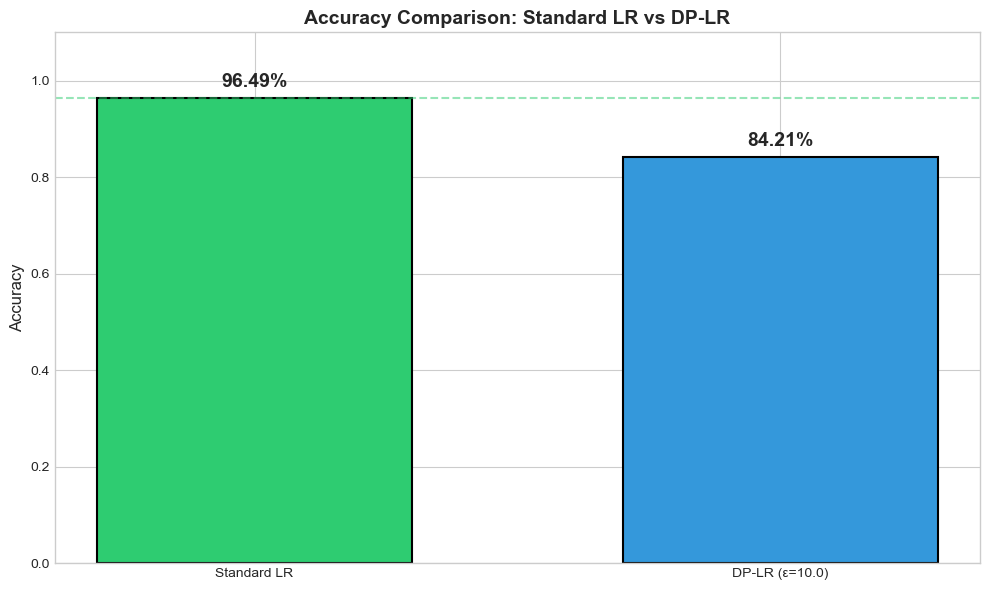

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

# Best DP accuracy (epsilon=10.0)
best_dp_accuracy = dp_report['epsilon_results']['10.0']['accuracy']

models = ['Standard LR', 'DP-LR (ε=10.0)']
accuracies = [std_accuracy, best_dp_accuracy]
colors = [COLORS['std'], COLORS['dp']]

bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.annotate(f'{acc:.2%}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=14, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy Comparison: Standard LR vs DP-LR', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(y=std_accuracy, color=COLORS['std'], linestyle='--', alpha=0.5, label='Standard LR Baseline')

plt.tight_layout()
plt.savefig('data/g1_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Graph 2: Epsilon vs Accuracy Line Plot
Shows how DP accuracy improves with increasing epsilon

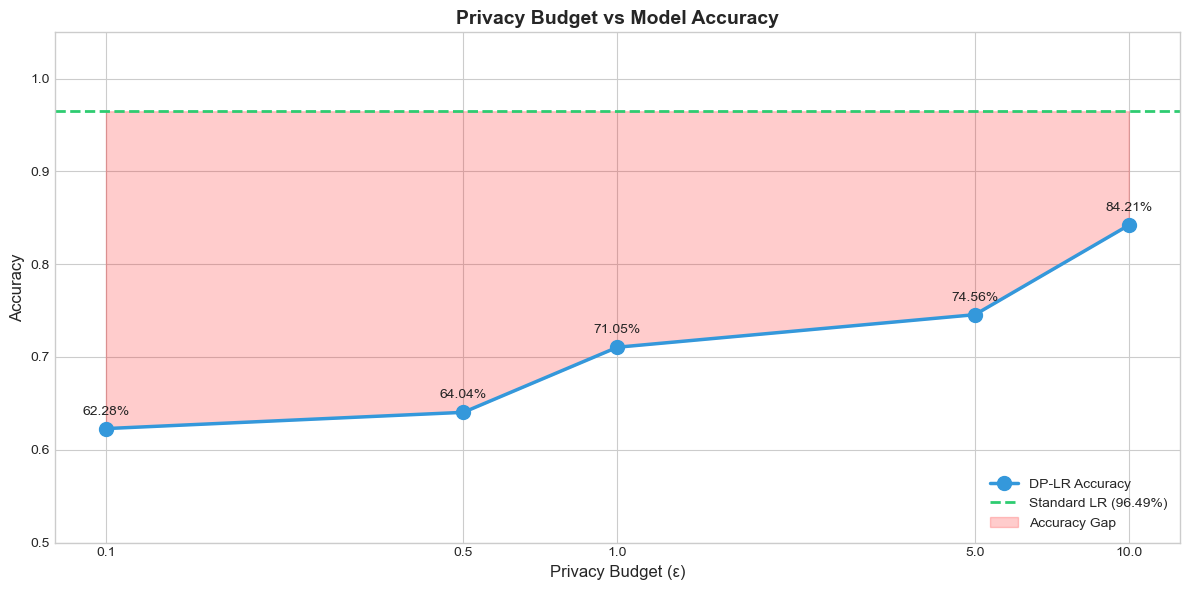

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot DP accuracy line
ax.plot(epsilon_values, dp_accuracies, 'o-', color=COLORS['dp'], 
        linewidth=2.5, markersize=10, label='DP-LR Accuracy')

# Plot Standard LR baseline
ax.axhline(y=std_accuracy, color=COLORS['std'], linestyle='--', 
           linewidth=2, label=f'Standard LR ({std_accuracy:.2%})')

# Fill area between DP and Standard
ax.fill_between(epsilon_values, dp_accuracies, std_accuracy, 
                alpha=0.2, color='red', label='Accuracy Gap')

# Add value labels
for e, acc in zip(epsilon_values, dp_accuracies):
    ax.annotate(f'{acc:.2%}', (e, acc), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=10)

ax.set_xlabel('Privacy Budget (ε)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Privacy Budget vs Model Accuracy', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_xticks(epsilon_values)
ax.set_xticklabels([str(e) for e in epsilon_values])
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig('data/g2_epsilon_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Graph 3: Privacy-Utility Tradeoff
Visualization of epsilon values vs accuracy loss compared to standard

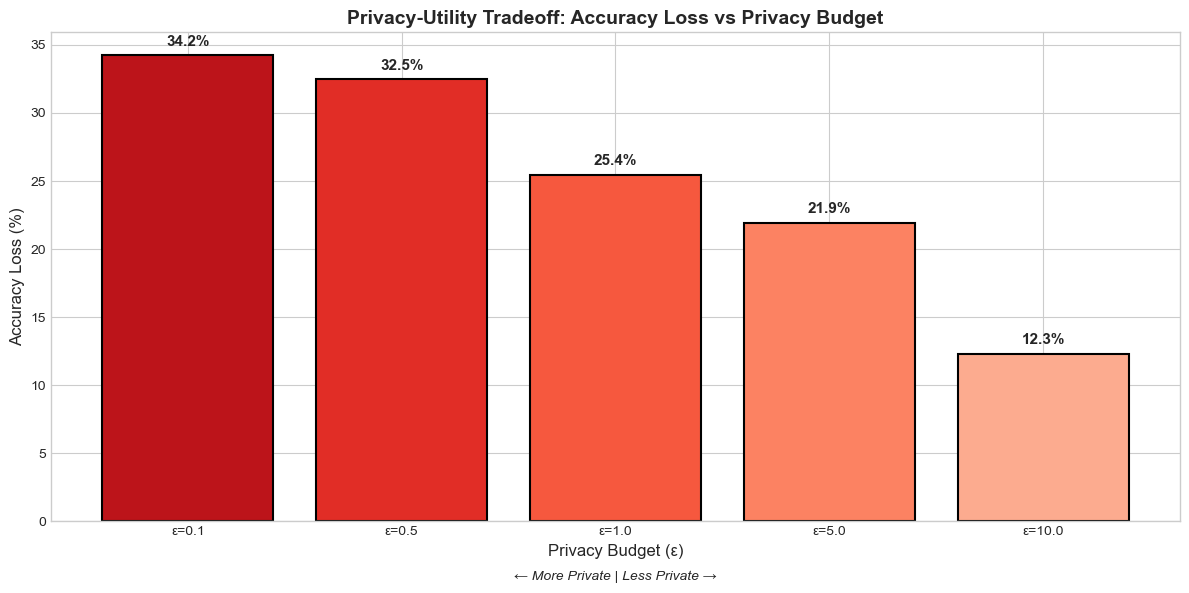

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate accuracy loss
accuracy_loss = [(std_accuracy - acc) * 100 for acc in dp_accuracies]

# Create bar chart
bars = ax.bar(range(len(epsilon_values)), accuracy_loss, 
              color=plt.cm.Reds(np.linspace(0.8, 0.3, len(epsilon_values))),
              edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, loss) in enumerate(zip(bars, accuracy_loss)):
    ax.annotate(f'{loss:.1f}%', 
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Privacy Budget (ε)', fontsize=12)
ax.set_ylabel('Accuracy Loss (%)', fontsize=12)
ax.set_title('Privacy-Utility Tradeoff: Accuracy Loss vs Privacy Budget', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(epsilon_values)))
ax.set_xticklabels([f'ε={e}' for e in epsilon_values])

# Add annotations
ax.annotate('← More Private | Less Private →', xy=(0.5, -0.12), 
            xycoords='axes fraction', ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('data/g3_privacy_utility_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Graph 4: Confusion Matrix Heatmaps
Side-by-side: Standard LR vs DP-LR (at ε=10.0)

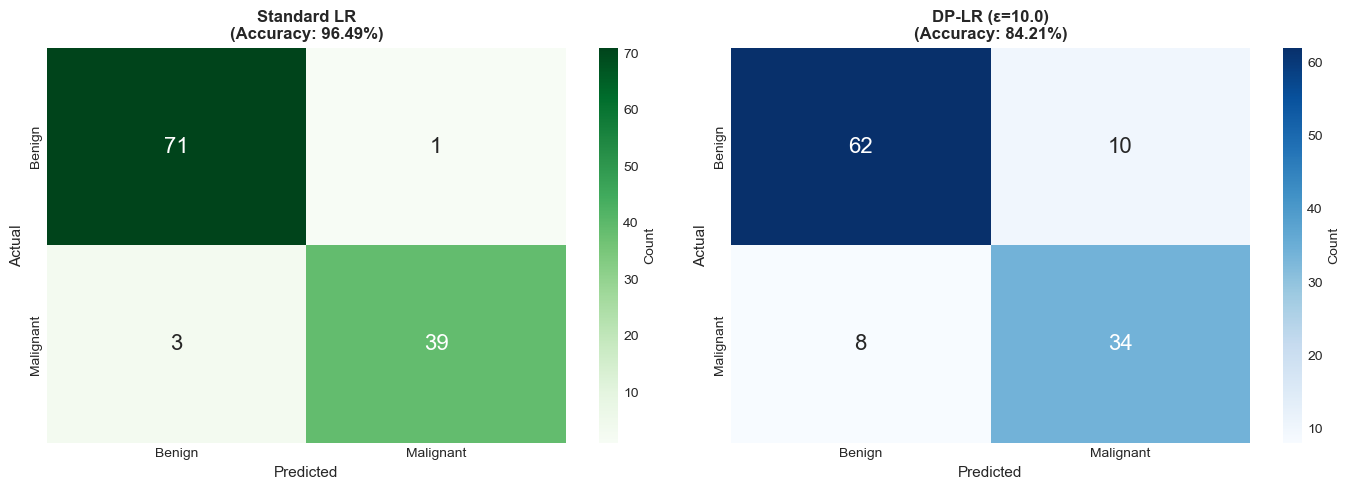

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Benign', 'Malignant']

# Standard LR Confusion Matrix
cm_std = np.array(std_report['confusion_matrix'])
sns.heatmap(cm_std, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=labels, yticklabels=labels, 
            annot_kws={'size': 16}, cbar_kws={'label': 'Count'})
axes[0].set_title(f'Standard LR\n(Accuracy: {std_accuracy:.2%})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

# DP-LR Confusion Matrix (epsilon=10.0)
cm_dp = np.array(dp_report['epsilon_results']['10.0']['confusion_matrix'])
dp_acc = dp_report['epsilon_results']['10.0']['accuracy']
sns.heatmap(cm_dp, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 16}, cbar_kws={'label': 'Count'})
axes[1].set_title(f'DP-LR (ε=10.0)\n(Accuracy: {dp_acc:.2%})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('data/g4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Graph 5: Per-Class Precision Comparison
Grouped bar chart for Benign & Malignant precision

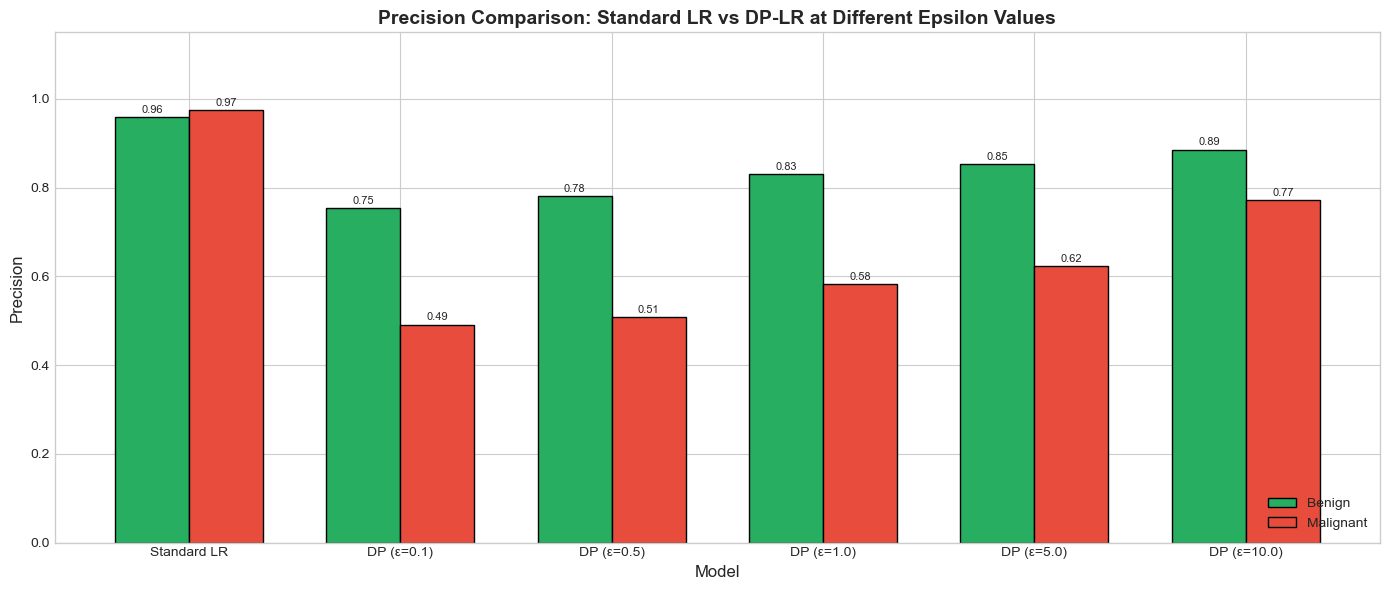

In [39]:
fig, ax = plt.subplots(figsize=(14, 6))

# Extract precision values
std_benign_prec = std_report['classification_report']['Benign']['precision']
std_malig_prec = std_report['classification_report']['Malignant']['precision']

dp_benign_prec = [dp_report['epsilon_results'][str(e)]['classification_report']['Benign']['precision'] 
                  for e in epsilon_values]
dp_malig_prec = [dp_report['epsilon_results'][str(e)]['classification_report']['Malignant']['precision'] 
                 for e in epsilon_values]

x = np.arange(len(epsilon_values) + 1)
width = 0.35

benign_vals = [std_benign_prec] + dp_benign_prec
malig_vals = [std_malig_prec] + dp_malig_prec

bars1 = ax.bar(x - width/2, benign_vals, width, label='Benign', color=COLORS['benign'], edgecolor='black')
bars2 = ax.bar(x + width/2, malig_vals, width, label='Malignant', color=COLORS['malignant'], edgecolor='black')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision Comparison: Standard LR vs DP-LR at Different Epsilon Values', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Standard LR'] + [f'DP (ε={e})' for e in epsilon_values])
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('data/g5_precision_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Graph 6: Per-Class Recall Comparison
Grouped bar chart for Benign & Malignant recall

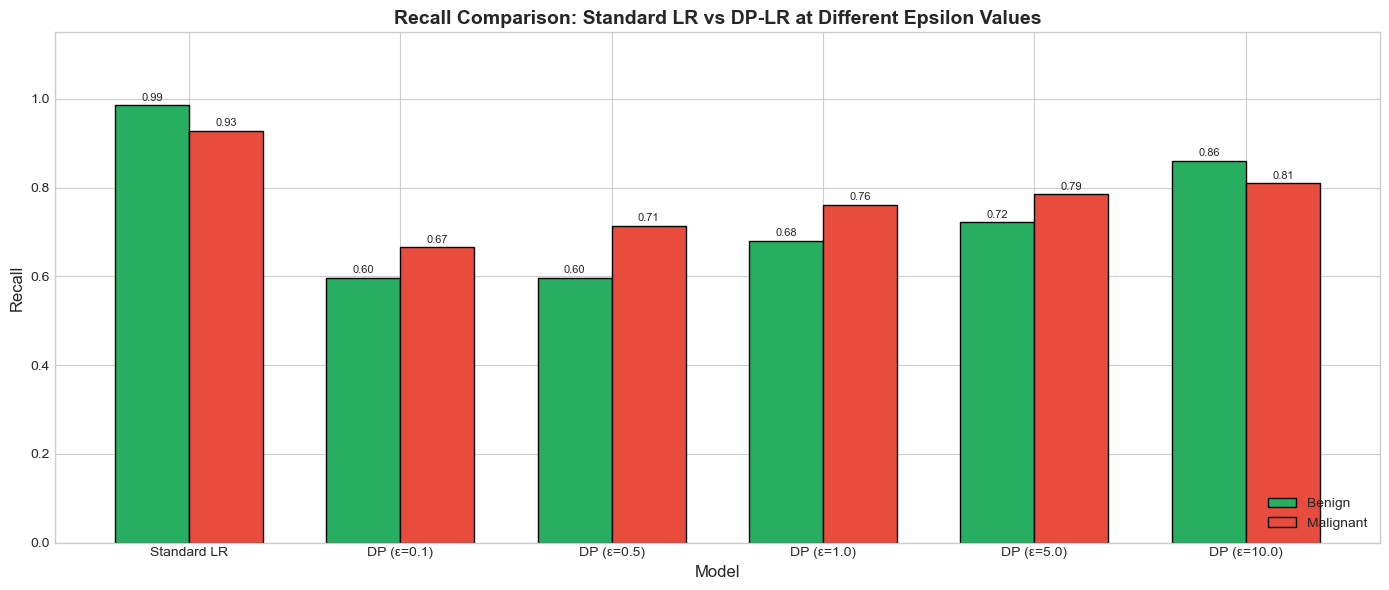

In [40]:
fig, ax = plt.subplots(figsize=(14, 6))

# Extract recall values
std_benign_rec = std_report['classification_report']['Benign']['recall']
std_malig_rec = std_report['classification_report']['Malignant']['recall']

dp_benign_rec = [dp_report['epsilon_results'][str(e)]['classification_report']['Benign']['recall'] 
                 for e in epsilon_values]
dp_malig_rec = [dp_report['epsilon_results'][str(e)]['classification_report']['Malignant']['recall'] 
                for e in epsilon_values]

x = np.arange(len(epsilon_values) + 1)
width = 0.35

benign_vals = [std_benign_rec] + dp_benign_rec
malig_vals = [std_malig_rec] + dp_malig_rec

bars1 = ax.bar(x - width/2, benign_vals, width, label='Benign', color=COLORS['benign'], edgecolor='black')
bars2 = ax.bar(x + width/2, malig_vals, width, label='Malignant', color=COLORS['malignant'], edgecolor='black')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('Recall Comparison: Standard LR vs DP-LR at Different Epsilon Values', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Standard LR'] + [f'DP (ε={e})' for e in epsilon_values])
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('data/g6_recall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Graph 7: Per-Class F1-Score Comparison
Grouped bar chart for Benign & Malignant F1-score

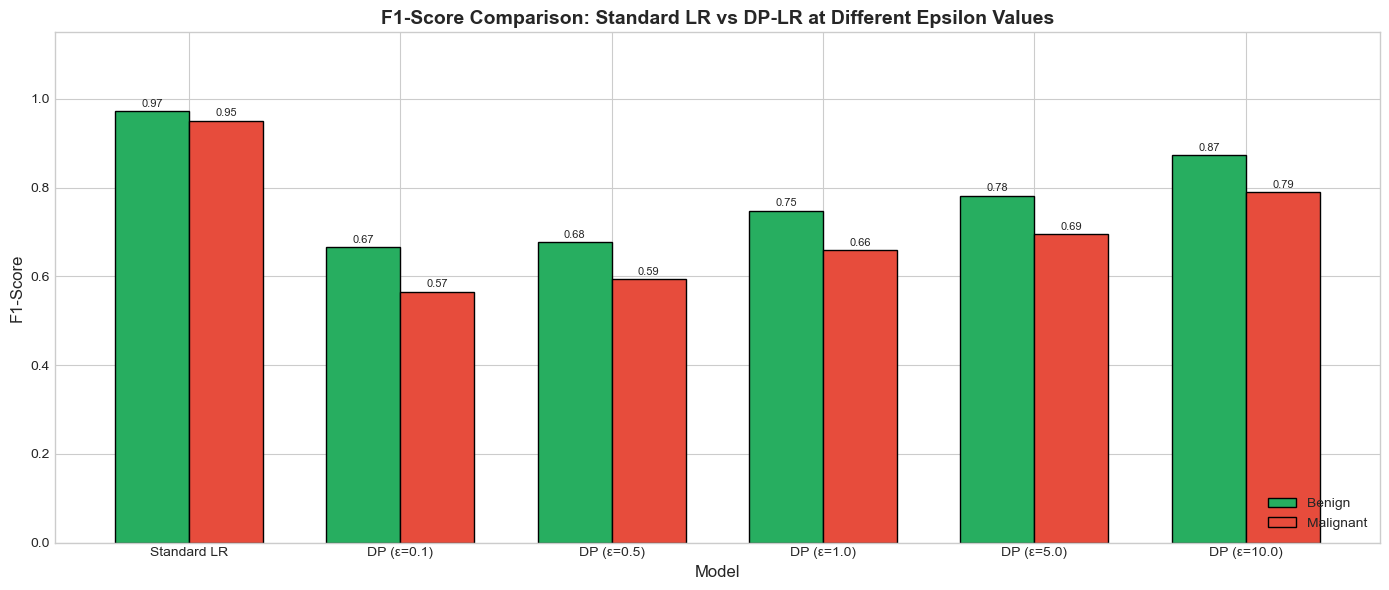

In [41]:
fig, ax = plt.subplots(figsize=(14, 6))

# Extract F1 values
std_benign_f1 = std_report['classification_report']['Benign']['f1-score']
std_malig_f1 = std_report['classification_report']['Malignant']['f1-score']

dp_benign_f1 = [dp_report['epsilon_results'][str(e)]['classification_report']['Benign']['f1-score'] 
                for e in epsilon_values]
dp_malig_f1 = [dp_report['epsilon_results'][str(e)]['classification_report']['Malignant']['f1-score'] 
               for e in epsilon_values]

x = np.arange(len(epsilon_values) + 1)
width = 0.35

benign_vals = [std_benign_f1] + dp_benign_f1
malig_vals = [std_malig_f1] + dp_malig_f1

bars1 = ax.bar(x - width/2, benign_vals, width, label='Benign', color=COLORS['benign'], edgecolor='black')
bars2 = ax.bar(x + width/2, malig_vals, width, label='Malignant', color=COLORS['malignant'], edgecolor='black')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('F1-Score Comparison: Standard LR vs DP-LR at Different Epsilon Values', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Standard LR'] + [f'DP (ε={e})' for e in epsilon_values])
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('data/g7_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Graph 8: Metrics Radar Chart
Compare all metrics for Standard vs DP-LR (ε=10)

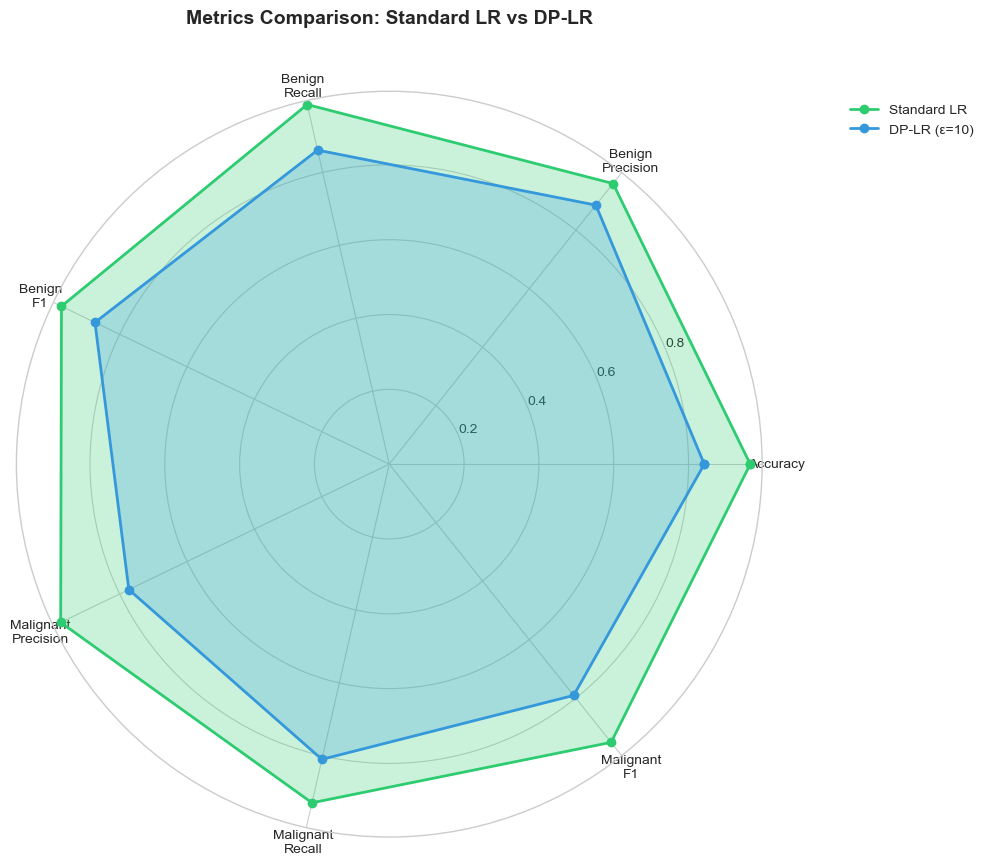

In [42]:
from math import pi

# Prepare data for radar chart
categories = ['Accuracy', 'Benign\nPrecision', 'Benign\nRecall', 'Benign\nF1', 
              'Malignant\nPrecision', 'Malignant\nRecall', 'Malignant\nF1']

# Standard LR values
std_values = [
    std_report['accuracy'],
    std_report['classification_report']['Benign']['precision'],
    std_report['classification_report']['Benign']['recall'],
    std_report['classification_report']['Benign']['f1-score'],
    std_report['classification_report']['Malignant']['precision'],
    std_report['classification_report']['Malignant']['recall'],
    std_report['classification_report']['Malignant']['f1-score']
]

# DP-LR values (epsilon=10.0)
dp_10 = dp_report['epsilon_results']['10.0']
dp_values = [
    dp_10['accuracy'],
    dp_10['classification_report']['Benign']['precision'],
    dp_10['classification_report']['Benign']['recall'],
    dp_10['classification_report']['Benign']['f1-score'],
    dp_10['classification_report']['Malignant']['precision'],
    dp_10['classification_report']['Malignant']['recall'],
    dp_10['classification_report']['Malignant']['f1-score']
]

# Number of variables
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the loop

# Close the plots
std_values += std_values[:1]
dp_values += dp_values[:1]

# Create figure
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Plot Standard LR
ax.plot(angles, std_values, 'o-', linewidth=2, label='Standard LR', color=COLORS['std'])
ax.fill(angles, std_values, alpha=0.25, color=COLORS['std'])

# Plot DP-LR
ax.plot(angles, dp_values, 'o-', linewidth=2, label='DP-LR (ε=10)', color=COLORS['dp'])
ax.fill(angles, dp_values, alpha=0.25, color=COLORS['dp'])

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)

# Add legend and title
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.set_title('Metrics Comparison: Standard LR vs DP-LR', fontsize=14, fontweight='bold', y=1.08)

plt.tight_layout()
plt.savefig('data/g8_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Graph 9: Accuracy Gap Analysis
Bar chart showing accuracy drop at each epsilon compared to standard

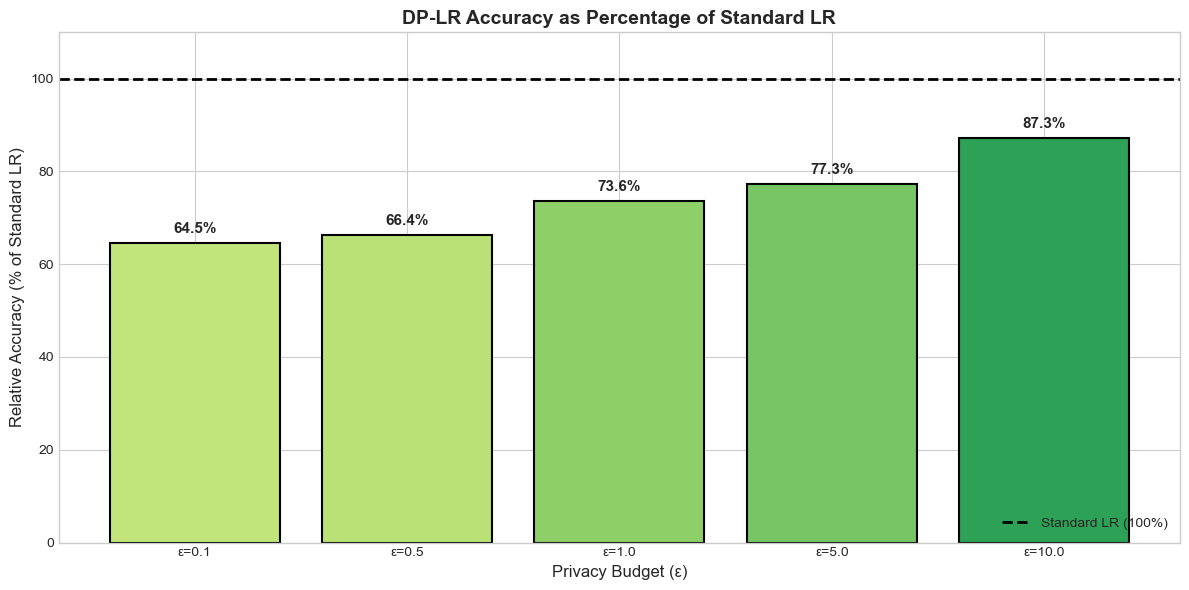

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate relative accuracy (% of standard)
relative_accuracy = [(acc / std_accuracy) * 100 for acc in dp_accuracies]

# Create gradient colors
colors = plt.cm.RdYlGn(np.array(relative_accuracy) / 100)

bars = ax.bar(range(len(epsilon_values)), relative_accuracy, 
              color=colors, edgecolor='black', linewidth=1.5)

# Add 100% baseline
ax.axhline(y=100, color='black', linestyle='--', linewidth=2, label='Standard LR (100%)')

# Add value labels
for i, (bar, rel_acc) in enumerate(zip(bars, relative_accuracy)):
    ax.annotate(f'{rel_acc:.1f}%', 
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Privacy Budget (ε)', fontsize=12)
ax.set_ylabel('Relative Accuracy (% of Standard LR)', fontsize=12)
ax.set_title('DP-LR Accuracy as Percentage of Standard LR', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(epsilon_values)))
ax.set_xticklabels([f'ε={e}' for e in epsilon_values])
ax.set_ylim(0, 110)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('data/g9_accuracy_gap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Graph 10: Summary Table Visualization
Visual table comparing key metrics side-by-side

In [44]:
# Create summary DataFrame
summary_data = {
    'Model': ['Standard LR'] + [f'DP-LR (ε={e})' for e in epsilon_values],
    'Accuracy': [std_accuracy] + dp_accuracies,
    'Benign Precision': [std_report['classification_report']['Benign']['precision']] + 
                        [dp_report['epsilon_results'][str(e)]['classification_report']['Benign']['precision'] for e in epsilon_values],
    'Benign Recall': [std_report['classification_report']['Benign']['recall']] + 
                     [dp_report['epsilon_results'][str(e)]['classification_report']['Benign']['recall'] for e in epsilon_values],
    'Malignant Precision': [std_report['classification_report']['Malignant']['precision']] + 
                           [dp_report['epsilon_results'][str(e)]['classification_report']['Malignant']['precision'] for e in epsilon_values],
    'Malignant Recall': [std_report['classification_report']['Malignant']['recall']] + 
                        [dp_report['epsilon_results'][str(e)]['classification_report']['Malignant']['recall'] for e in epsilon_values]
}

summary_df = pd.DataFrame(summary_data)

# Format as percentages for display
display_df = summary_df.copy()
for col in display_df.columns[1:]:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.2%}')

print("\n" + "="*80)
print("SUMMARY COMPARISON TABLE")
print("="*80)
display(display_df)


SUMMARY COMPARISON TABLE


,Model,Accuracy,Benign Precision,Benign Recall,Malignant Precision,Malignant Recall
0,Standard LR,96.49%,95.95%,98.61%,97.50%,92.86%
1,DP-LR (ε=0.1),62.28%,75.44%,59.72%,49.12%,66.67%
2,DP-LR (ε=0.5),64.04%,78.18%,59.72%,50.85%,71.43%
3,DP-LR (ε=1.0),71.05%,83.05%,68.06%,58.18%,76.19%
4,DP-LR (ε=5.0),74.56%,85.25%,72.22%,62.26%,78.57%
5,DP-LR (ε=10.0),84.21%,88.57%,86.11%,77.27%,80.95%


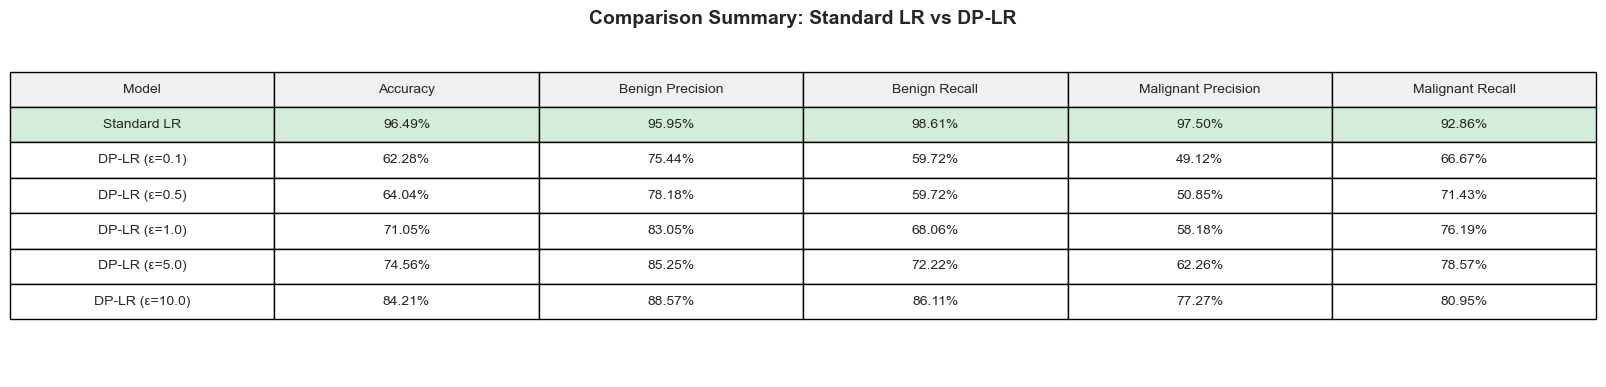

In [45]:
# Visual table using matplotlib
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

# Create table
table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    colColours=['#f0f0f0']*len(display_df.columns)
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Color the first row (Standard LR) differently
for j in range(len(display_df.columns)):
    table[(1, j)].set_facecolor('#d4edda')  # Light green for Standard LR

plt.title('Comparison Summary: Standard LR vs DP-LR', fontsize=14, fontweight='bold', y=0.95)
plt.tight_layout()
plt.savefig('data/g10_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary & Conclusions

In [46]:
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 Standard LR Accuracy: {std_accuracy:.2%}")
print(f"\n📊 DP-LR Accuracy Range:")
for e, acc in zip(epsilon_values, dp_accuracies):
    gap = (std_accuracy - acc) * 100
    print(f"   ε={e:>4}: {acc:.2%} (Gap: -{gap:.1f}%)")

print(f"\n🎯 Best DP-LR Performance: ε=10.0 with {dp_accuracies[-1]:.2%} accuracy")
print(f"   → Only {(std_accuracy - dp_accuracies[-1]) * 100:.1f}% lower than Standard LR")

print(f"\n🔒 Privacy-Utility Tradeoff:")
print(f"   → At ε=0.1 (high privacy): {dp_accuracies[0]:.2%} accuracy")
print(f"   → At ε=10.0 (lower privacy): {dp_accuracies[-1]:.2%} accuracy")
print(f"   → Improvement: +{(dp_accuracies[-1] - dp_accuracies[0]) * 100:.1f}%")

print("\n" + "="*80)
print("All 10 graphs have been saved to the 'data/' directory.")
print("="*80)


ANALYSIS SUMMARY

📊 Standard LR Accuracy: 96.49%

📊 DP-LR Accuracy Range:
   ε= 0.1: 62.28% (Gap: -34.2%)
   ε= 0.5: 64.04% (Gap: -32.5%)
   ε= 1.0: 71.05% (Gap: -25.4%)
   ε= 5.0: 74.56% (Gap: -21.9%)
   ε=10.0: 84.21% (Gap: -12.3%)

🎯 Best DP-LR Performance: ε=10.0 with 84.21% accuracy
   → Only 12.3% lower than Standard LR

🔒 Privacy-Utility Tradeoff:
   → At ε=0.1 (high privacy): 62.28% accuracy
   → At ε=10.0 (lower privacy): 84.21% accuracy
   → Improvement: +21.9%

All 10 graphs have been saved to the 'data/' directory.


In [47]:
# Save comparison summary to CSV
summary_df.to_csv('data/std_dp_comparison_summary.csv', index=False)
print("Summary saved to data/std_dp_comparison_summary.csv")

Summary saved to data/std_dp_comparison_summary.csv
